<a href="https://colab.research.google.com/github/SanjnaGujral5/fl_based_intrusion_detection_system/blob/FLintro/FL_IDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# New Section

# New Section

In [3]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

train_df = pd.read_csv('/content/drive/MyDrive/FL_IDS_UNSW/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/FL_IDS_UNSW/UNSW_NB15_testing-set.csv')




MessageError: Error: credential propagation was unsuccessful

In [4]:
!pip install gdown
import gdown
import pandas as pd

# Your CSV files from Drive
train_file_id = "1w6i_ZDWzyWPQvbWmLjq12qHN0ZgQJo5T"
test_file_id  = "1FHGsG0Dgf9Fx2TNMzu9phbcx7qixyeoP"

train_url = f"https://drive.google.com/uc?id={train_file_id}"
test_url  = f"https://drive.google.com/uc?id={test_file_id}"

train_df = pd.read_csv(train_url)
test_df  = pd.read_csv(test_url)

train_df.head()


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [5]:
# ==========================================================
# Intrusion Detection System using UNSW-NB15 Dataset
# Models:
#   1. Logistic Regression
#   2. Random Forest
#   3. CNN
# ==========================================================


# ==========================================================
# 1. Import Required Libraries
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    auc
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

from imblearn.over_sampling import SMOTE

In [7]:

# ==========================================================

# Remove unnecessary column
train_df = train_df.drop(columns=['id'], errors='ignore')
test_df  = test_df.drop(columns=['id'], errors='ignore')


# ==========================================================
# 5. Encode Categorical Features
# ==========================================================

categorical_cols = ['proto', 'service', 'state']

encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    train_df[col] = le.fit_transform(train_df[col])

    encoders[col] = le

    # Handle unseen labels in test dataset
    test_df[col] = test_df[col].map(
        lambda s: le.transform([s])[0] if s in le.classes_ else -1
    )



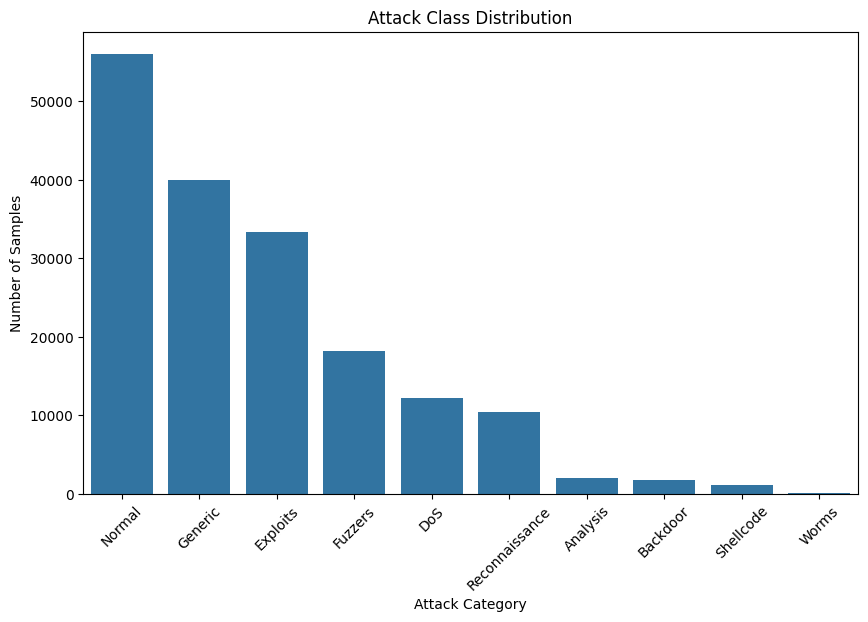

In [8]:

# ==========================================================
# 6. Handle Missing Values
# ==========================================================

train_df = train_df.fillna(train_df.mean(numeric_only=True))
test_df  = test_df.fillna(test_df.mean(numeric_only=True))
# =========================================
# Attack Class Distribution
# =========================================

plt.figure(figsize=(10,6))

sns.countplot(
    data=train_df,
    x='attack_cat',
    order=train_df['attack_cat'].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Attack Class Distribution")

plt.xlabel("Attack Category")
plt.ylabel("Number of Samples")

plt.show()

In [9]:
# ==========================================================
# 7. Remove Attack Category Column
# ==========================================================

train_df = train_df.drop(columns=['attack_cat'], errors='ignore')
test_df  = test_df.drop(columns=['attack_cat'], errors='ignore')


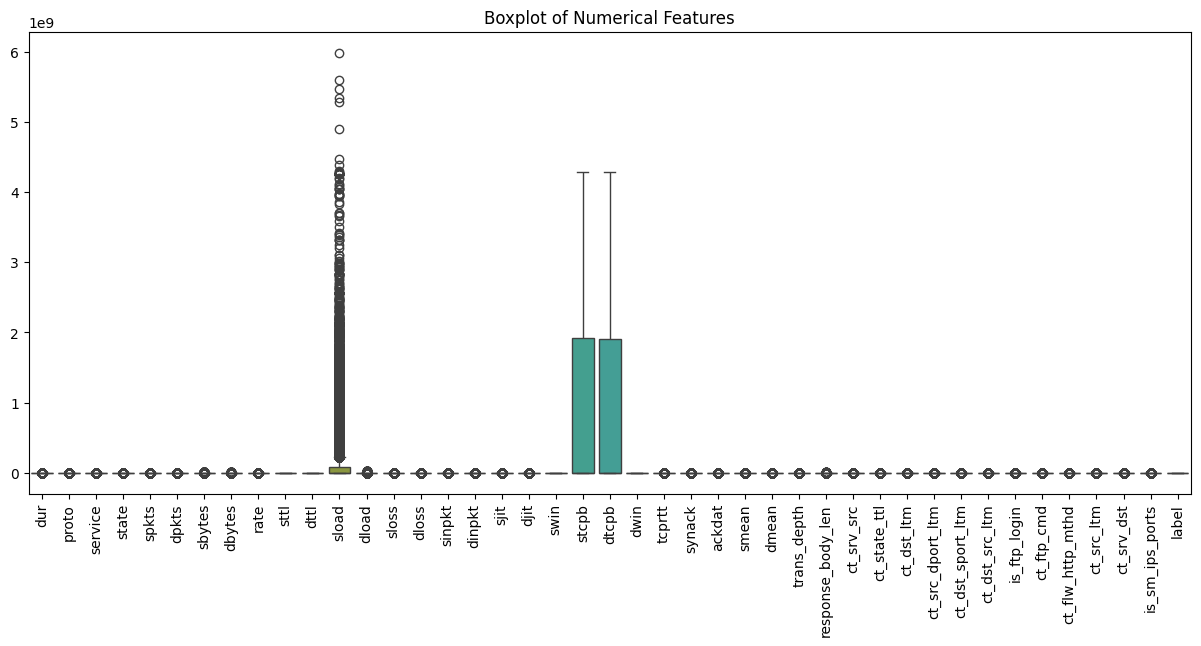

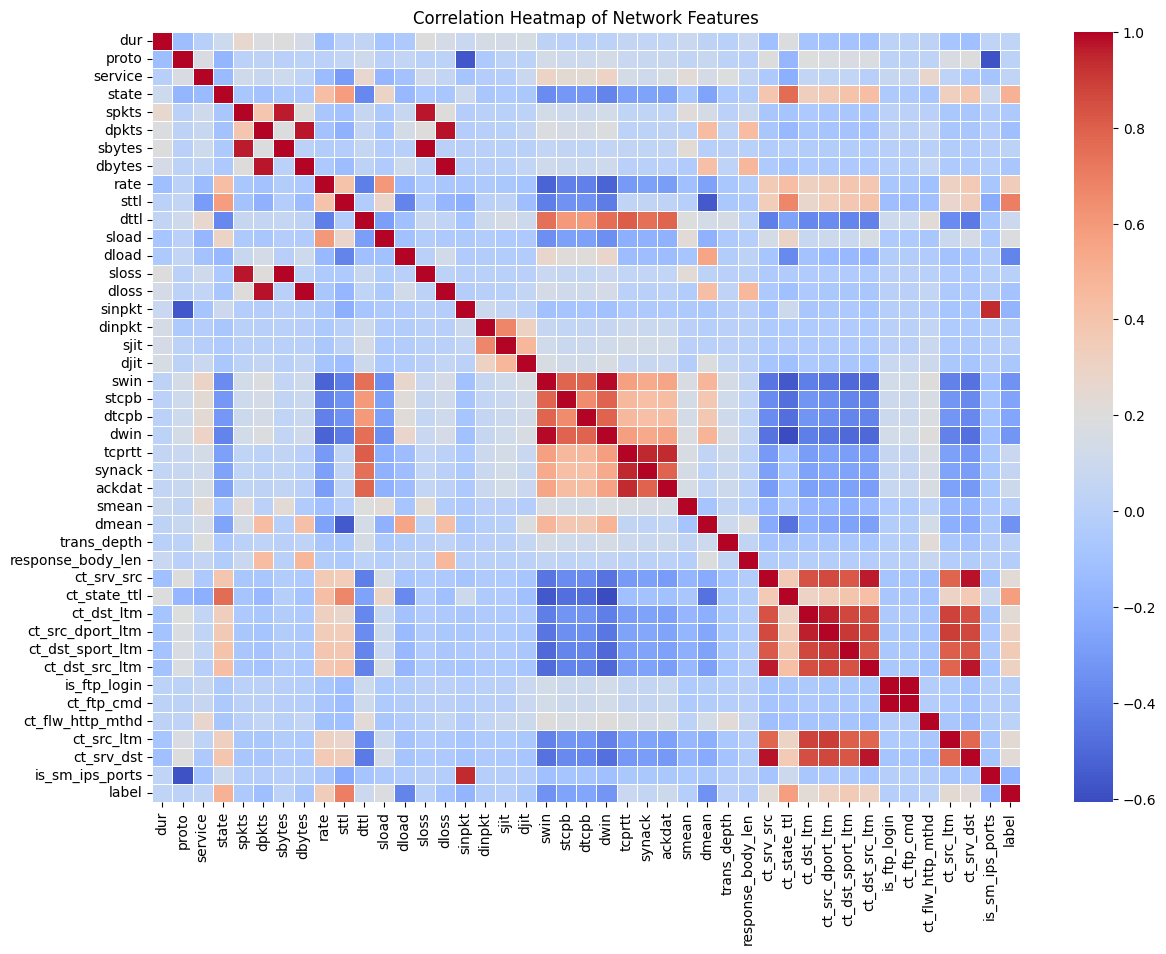

In [10]:
# ==========================================================
# 8. Exploratory Data Analysis
# ==========================================================

# ------------------------------
# Boxplot Visualization
# ------------------------------

plt.figure(figsize=(15,6))

sns.boxplot(data=train_df.select_dtypes(include=np.number))

plt.xticks(rotation=90)
plt.title("Boxplot of Numerical Features")

plt.show()


# ------------------------------
# Correlation Heatmap
# ------------------------------

plt.figure(figsize=(14,10))

corr = train_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap of Network Features")

plt.show()

In [11]:
# ==========================================================
# 9. Feature Selection (Chi-Square)
# ==========================================================

X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

selector = SelectKBest(score_func=chi2, k=20)

X_train_selected = selector.fit_transform(abs(X_train), y_train)

selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
print(selected_features)


# Apply same selected features to test dataset
X_test = test_df[selected_features]
y_test = test_df['label']


Selected Features:
Index(['spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload',
       'dload', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'dmean', 'response_body_len'],
      dtype='object')


In [12]:
# ==========================================================
# 10. Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_df[selected_features])
X_test_scaled  = scaler.transform(X_test)



In [13]:
# ==========================================================
# Handle Class Imbalance using SMOTE
# ==========================================================

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before balancing:")
print(y_train.value_counts())

print("After balancing:")
print(pd.Series(y_train_balanced).value_counts())

Before balancing:
label
1    119341
0     56000
Name: count, dtype: int64
After balancing:
label
0    119341
1    119341
Name: count, dtype: int64


In [16]:
# ==========================================================
# PREPARE DATA FOR FEDERATED CLIENTS
# ==========================================================

train_data = pd.DataFrame(X_train_scaled, columns=selected_features)

train_data["label"] = y_train.values

print("Combined training data shape:", train_data.shape)


Combined training data shape: (175341, 21)


In [17]:
# ==========================================================
#  CREATE FEDERATED CLIENTS
# ==========================================================

import numpy as np

def create_clients(data, num_clients=10):

    """
    Splits dataset into multiple client datasets
    """

    # Shuffle dataset
    data = data.sample(frac=1).reset_index(drop=True)

    # Split dataset into equal parts
    client_data = np.array_split(data, num_clients)

    clients = {}

    for i in range(num_clients):

        clients[f"client_{i+1}"] = client_data[i]

    return clients

    # Create 10 federated clients
clients = create_clients(train_data, num_clients=10)

print("Total clients:", len(clients))

# Check one client dataset
clients["client_1"].head()



Total clients: 10


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,dloss,...,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,dmean,response_body_len,label
0,-0.133677,-0.153908,-0.049774,-0.102684,-0.557253,-1.443048,-0.457978,-0.386628,0.040005,-0.131759,...,-0.089367,-0.110668,-0.148818,-0.915407,-0.715177,-0.715569,-0.906432,-0.136164,-0.039557,0
1,0.319251,0.426549,-0.028832,0.256722,-0.545507,-1.443048,-0.457978,-0.383583,6.491036,0.361293,...,-0.088986,-0.110203,-0.143747,1.092456,0.406384,1.994855,1.103244,2.558207,-0.039557,0
2,-0.133677,-0.172047,-0.049958,-0.103923,1.438491,0.723268,-0.720406,0.417006,-0.277208,-0.131759,...,-0.089370,-0.110668,-0.148818,-0.915407,-0.715177,-0.715569,-0.906432,-0.480703,-0.039557,1
3,-0.075235,-0.117630,-0.047554,-0.102057,-0.576674,0.723268,1.560002,-0.389940,-0.276020,-0.112795,...,0.019633,-0.030785,-0.103994,1.092456,0.138253,-0.056998,1.103244,-0.306498,-0.039557,0
4,-0.133677,-0.172047,-0.049649,-0.103923,0.094951,0.723268,-0.720406,0.006438,-0.277208,-0.131759,...,-0.089370,-0.110668,-0.148818,-0.915407,-0.715177,-0.715569,-0.906432,-0.480703,-0.039557,1


In [18]:
for client_name, data in clients.items():
    print(client_name, data.shape)


client_1 (17535, 21)
client_2 (17534, 21)
client_3 (17534, 21)
client_4 (17534, 21)
client_5 (17534, 21)
client_6 (17534, 21)
client_7 (17534, 21)
client_8 (17534, 21)
client_9 (17534, 21)
client_10 (17534, 21)


In [20]:
# ==========================================================
# DEFINE GLOBAL MODEL
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

def create_model(input_shape):

    model = Sequential()

    model.add(Conv1D(64, 3, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(2))

    model.add(Conv1D(128, 3, activation='relu'))
    model.add(MaxPooling1D(2))

    model.add(Flatten())

    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


In [21]:
# Input shape for CNN
input_shape = (len(selected_features), 1)

# Create global model
global_model = create_model(input_shape)

print("Global model created")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Global model created


In [22]:
# ==========================================================
# LOCAL CLIENT TRAINING
# ==========================================================

def train_client(client_data, global_weights):

    # Split features and labels
    X = client_data.drop(columns=["label"]).values
    y = client_data["label"].values

    # Reshape for CNN
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # Create model
    model = create_model((X.shape[1],1))

    # Load global weights
    model.set_weights(global_weights)

    # Train locally
    model.fit(
        X,
        y,
        epochs=1,
        batch_size=64,
        verbose=0
    )

    return model.get_weights()


In [23]:
# ==========================================================
#  FEDERATED TRAINING LOOP
# ==========================================================

num_rounds = 5

global_weights = global_model.get_weights()

for round_num in range(num_rounds):

    print(f"\nFederated Round {round_num+1}")

    client_weights = []

    # Train each client
    for client_name, client_data in clients.items():

        print("Training", client_name)

        weights = train_client(client_data, global_weights)

        client_weights.append(weights)

    # Federated Averaging
    new_weights = []

    for weights_list_tuple in zip(*client_weights):

        new_weights.append(
            np.mean(weights_list_tuple, axis=0)
        )

    global_weights = new_weights

    global_model.set_weights(global_weights)

print("Federated training completed")



Federated Round 1
Training client_1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training client_2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training client_3


...

Training client_9


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training client_10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Federated training completed


In [24]:
# ==========================================================
# STEP 8: TEST GLOBAL FEDERATED MODEL
# ==========================================================

X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

y_pred = (global_model.predict(X_test_cnn) > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Federated CNN Results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)


2573/2573 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Federated CNN Results
Accuracy: 0.7860977505708594
Precision: 0.7206699463469775
Recall: 0.9985440748257302
F1 Score: 0.8371508095762092


Logistic Regression
Accuracy: 0.8135961715979206
Precision: 0.7585582478227128
Recall: 0.970285890761493
F1 Score: 0.8514571658100797

Random Forest
Accuracy: 0.8867633483943059
Precision: 0.8564047746303225
Recall: 0.9543589517338745
F1 Score: 0.9027324228734781

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1492/1492 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.9073 - loss: 0.2429 - val_accuracy: 0.8144 - val_loss: 0.3014
Epoch 2/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9184 - loss: 0.1876 - val_accuracy: 0.7891 - val_loss: 0.3285
Epoch 3/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9190 - loss: 0.1807 - val_accuracy: 0.7983 - val_loss: 0.2891
Epoch 4/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9205 - loss: 0.1736 - val_accuracy: 0.8104 - val_loss: 0.2755
Epoch 5/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9217 - loss: 0.1676 - val_accuracy: 0.7977 - val_loss: 0.2705
Epoch 6/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.9199 - loss: 0.1696 - val_accuracy: 0.8031 - val_loss: 0.2693
Epoch 7/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9222 - loss: 0.1621 - val_accuracy: 0.7955 - val_loss: 0.2471
Epoch 8/20
1492/1492 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9222 - loss: 0.16

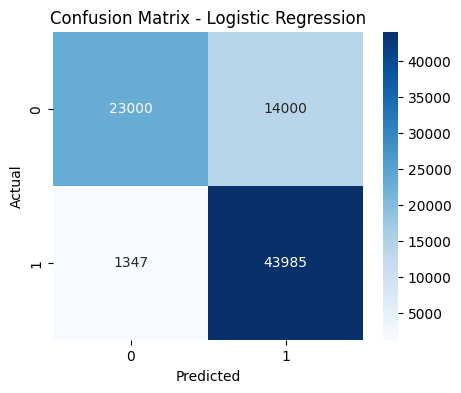

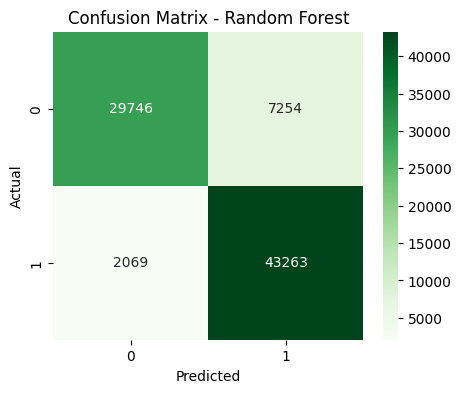

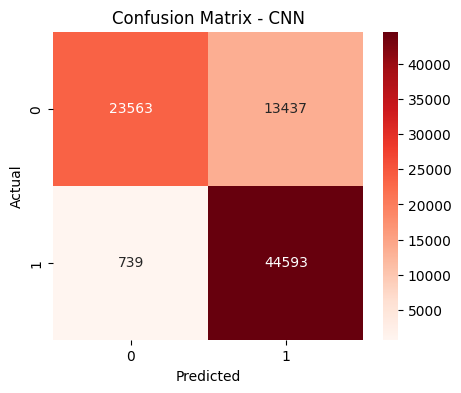

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.813596   0.758558  0.970286  0.851457
1        Random Forest  0.886763   0.856405  0.954359  0.902732
2                  CNN  0.827819   0.768447  0.983698  0.862851


In [25]:
# ==========================================================
# 12. Machine Learning Models
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

for name, model in models.items():

    model.fit(X_train_balanced, y_train_balanced)

    y_pred = model.predict(X_test_scaled)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    print(name)
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print()

    results.append([name, acc, prec, rec, f1])


# ==========================================================
# 13. CNN Model
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Reshape for CNN
X_train_cnn = X_train_balanced.reshape(
    X_train_balanced.shape[0],
    X_train_balanced.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

cnn_model = Sequential()

cnn_model.add(Conv1D(64, 3, activation='relu', input_shape=(X_train_cnn.shape[1],1)))
cnn_model.add(MaxPooling1D(2))

cnn_model.add(Conv1D(128, 3, activation='relu'))
cnn_model.add(MaxPooling1D(2))

cnn_model.add(Flatten())

cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(1, activation='sigmoid'))

cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = cnn_model.fit(
    X_train_cnn,
    y_train_balanced,
    epochs=20,
    batch_size=128,
    validation_split=0.2
)

# Prediction
y_pred_cnn = (cnn_model.predict(X_test_cnn) > 0.5).astype(int)

acc  = accuracy_score(y_test, y_pred_cnn)
prec = precision_score(y_test, y_pred_cnn)
rec  = recall_score(y_test, y_pred_cnn)
f1   = f1_score(y_test, y_pred_cnn)

print("CNN Results")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

results.append(["CNN", acc, prec, rec, f1])


# ==========================================================
# Confusion Matrices
# ==========================================================

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


# Logistic Regression
cm_lr = confusion_matrix(y_test, models["Logistic Regression"].predict(X_test_scaled))

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, models["Random Forest"].predict(X_test_scaled))

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# CNN
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Reds')
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ==========================================================
# Model Comparison Table
# ==========================================================

import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

print(results_df)



In [27]:
# ==========================================================
# 14. Model Comparison Table
# ==========================================================

results_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)

print(results_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.813596   0.758558  0.970286  0.851457
1        Random Forest  0.886763   0.856405  0.954359  0.902732
2                  CNN  0.827819   0.768447  0.983698  0.862851


In [28]:

# ==========================================================
# 16. Gradient Boosting Model
# ==========================================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred_gb)
prec = precision_score(y_test, y_pred_gb)
rec  = recall_score(y_test, y_pred_gb)
f1   = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results:")
print(acc, prec, rec, f1)

results.append(["Gradient Boosting", acc, prec, rec, f1])

Gradient Boosting Results:
0.8242724578535685 0.760464488252768 0.9939115856348716 0.8616561484031363


XGBoost Results:
0.8595928679006948 0.806605657842176 0.9799479396452837 0.8848674382009043


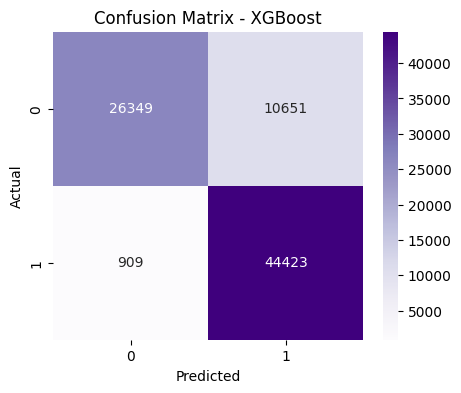

In [30]:
# ==========================================================
# 17. XGBoost Model
# ==========================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

acc  = accuracy_score(y_test, y_pred_xgb)
prec = precision_score(y_test, y_pred_xgb)
rec  = recall_score(y_test, y_pred_xgb)
f1   = f1_score(y_test, y_pred_xgb)

print("XGBoost Results:")
print(acc, prec, rec, f1)

results.append(["XGBoost", acc, prec, rec, f1])

# =========================================
# Confusion Matrix - XGBoost
# =========================================

from sklearn.metrics import confusion_matrix

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - XGBoost")

plt.show()